
## (o_prod_rt) model for PDF shaping (n samples)

This uses the new object oriented class for PDF shaping.

* o_prod_rt ...... i_h2i_rate, i_h2_temp, i_ng_rate, i_ng_temp, i_pci_rate, i_wpi_rate, i_sgi_rate, i_sgi_COH2ratio, i_sgi_ReProRatio, i_o2_volfract, i_hbtemp, i_wind_rt, i_blast_H2O, i_bdn_H2O

## Web applicationi inputs and 1 outputs

Run interactively on the web at: https://rcalix1.github.io/ProbabilityDensityFunctionsFromNeuralNets/experiments/2023/july2023/XGBoost/deployment/tuyere/




## Inputs


(2, 'i_h2i_rate').........i_h2i_rate

(3, 'i_pci_rate').........i_pci_rate

(4, 'i_wpi_rate').........i_wpi_rate

(5, 'i_ngi_rate').........i_ng_rate

(6, 'i_o2_volfract').......i_o2_volfract

(7, 'i_ng_temp')...........i_ng_temp

(8, 'i_h2_temp')...........i_h2_temp

(9, 'i_hbtemp')............i_hbtemp

(10, 'i_wind_rt')..........i_wind_rt

(11, 'i_blastH2O').........i_blast_H2O

(12, 'i_BdnH2O')............i_bdn_H2O

(13, 'i_sgi_rate').........i_sgi_rate

(15, 'i_sgi_COH2ratio').....i_sgi_COH2ratio

(16, 'i_sgi_ReProRatio')....i_sgi_ReProRatio


  

## Outputs


(39, 'o_prod_rt')





## Installs


In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime



## Imports


In [2]:

import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)




In [4]:

import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt



In [5]:

import PDFshapingUtils as PDF_tk



## Instantiate PDF shaping and regression class


In [6]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()



## Initialize parameters


In [7]:

PDFshapingOBJ.N_error_range = 5         ## 20
PDFshapingOBJ.mean_impulse  = 0.0       ## -7.0      ## 0.0
PDFshapingOBJ.std_impulse   = 0.001     ## 1.0
PDFshapingOBJ.kde_std       = 0.5       ## 0.1       ## 0.5      ## 3.0  ## smaller is better approximation?
PDFshapingOBJ.bandwidth     = 0.2       ## 0.2->more jagged, 2.0->more smooth


In [8]:

PDFshapingOBJ.initializeImpulseGaussian()



## Run checks


In [9]:

## print(PDFshapingOBJ.x_range_impulse_func )
## print(PDFshapingOBJ.impulse_func_vector_vals )
## print(PDFshapingOBJ.quadratic_weights)
print(PDFshapingOBJ.x_range_impulse_func.shape )
print(PDFshapingOBJ.impulse_func_vector_vals.shape )
print(PDFshapingOBJ.quadratic_weights.shape)
 
print( sum(PDFshapingOBJ.impulse_func_vector_vals) )      ## should add up to 100 (i.e. 1.0 prob density)


torch.Size([1000])
torch.Size([1000])
torch.Size([1000])
tensor(100.0000)


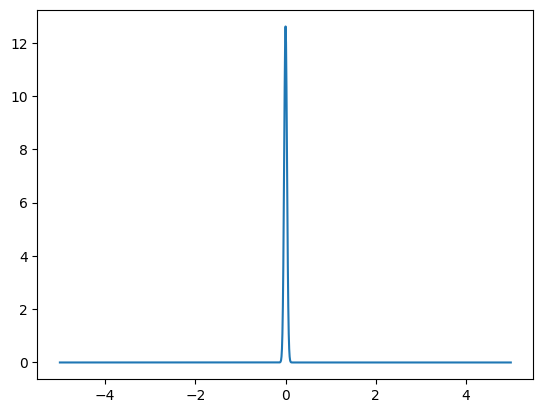

In [10]:

plt.plot(PDFshapingOBJ.x_range_impulse_func, PDFshapingOBJ.impulse_func_vector_vals)
plt.show()



## RUN KDE test


In [11]:

## PDFshapingOBJ.test_torchKDE_with_fake_data()



## Load Data


In [12]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.15.2025.csv')


In [13]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1200,...,18.7,45.4,145.0,312.0,821.0,24.2,22.6,57.4,4790.0,1890.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,17.9,30.2,160.0,345.0,930.0,40.7,17.0,57.6,5290.0,1910.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1480,...,18.2,39.1,191.0,413.0,1140.0,25.8,19.1,53.2,6330.0,2040.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,0,1600,...,19.6,29.6,166.0,360.0,977.0,40.3,16.5,58.8,5510.0,1980.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183,4184,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-0_H2T-600_HBT...,50,0,0,0,30,0,600,1600,...,18.3,40.2,336.0,726.0,2100.0,30.8,25.3,58.0,11100.0,2630.0
4184,4185,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1200,...,19.4,39.9,295.0,638.0,1790.0,32.9,28.1,57.7,9790.0,2200.0
4185,4186,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,18.1,42.0,295.0,639.0,1800.0,33.4,28.3,58.4,9780.0,2360.0
4186,4187,H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT...,50,0,0,0,30,300,0,1448,...,19.6,39.6,295.0,638.0,1800.0,33.3,28.2,58.3,9790.0,2310.0


In [14]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_COH2ratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_COH2ratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/numpy/lib/function_base.py:2691: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[:, None]
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/numpy/lib/function_base.py:2692: RuntimeWarning: invalid value encountered in true_divide
  c /= stddev[None, :]


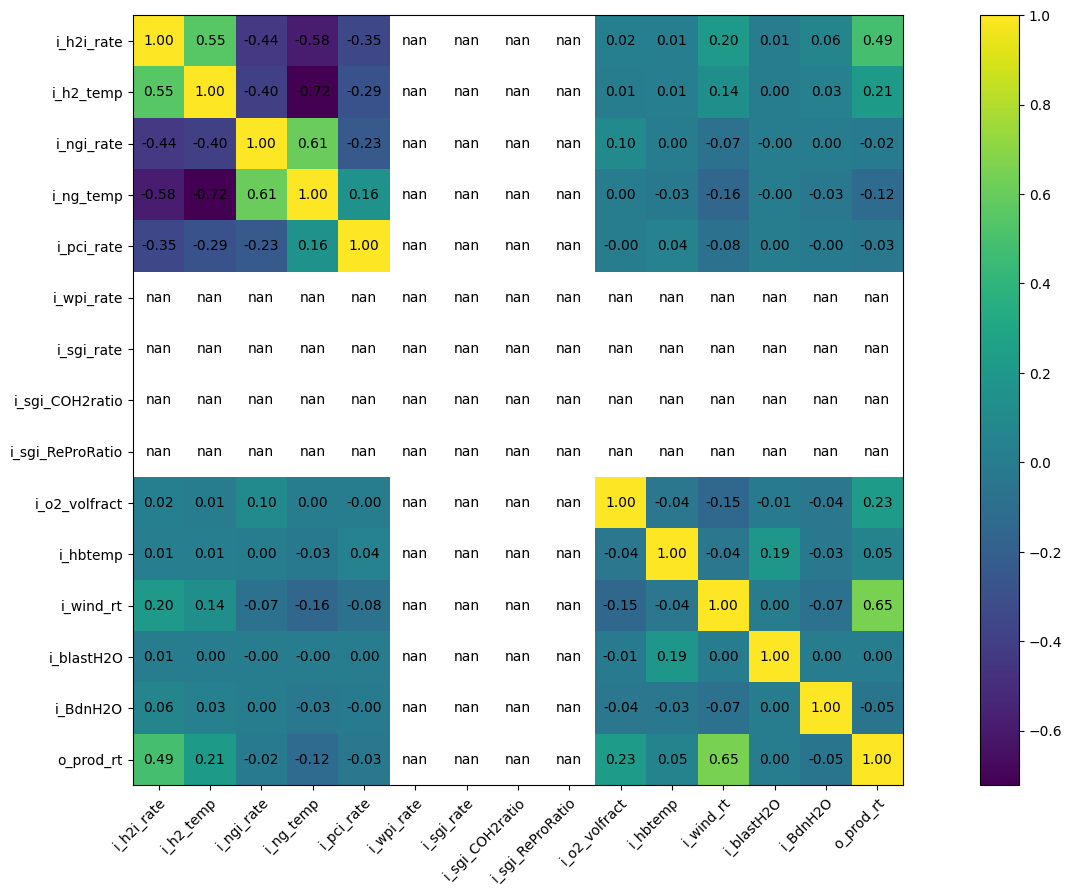

In [15]:

PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_sgi_rate','i_sgi_COH2ratio','i_sgi_ReProRatio','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','i_blastH2O','i_BdnH2O','o_prod_rt']

ONNX_name = 'o_prod_rt'


PDFshapingOBJ.print_correlation_coefficients()


In [16]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 60.6 4060.0 1850.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-230_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.4 4790.0 1890.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1480_WR-160_MHB-5.7_BM-1_SGI-0_SGT-0_SGC-0'
  0 ... 57.6 5290.0 1910.0]
 ...
 [4186
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-0_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.4 9780.0 2360.0]
 [4187
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1448_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 58.3 9790.0 2310.0]
 [4188
  'H2-50_PCI-0_WPI-0_NG-0_O2-30_NGT-300_H2T-0_HBT-1600_WR-195_MHB-11.4_BM-7_SGI-0_SGT-0_SGC-0'
  50 ... 57.9 9780.0 2400.0]]
(4188, 41)



## Select inputs and outputs


In [17]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [ 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16 ] , 
                   outputs= [ 39 ]   
)







14
1


In [18]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4188, 14)
(4188, 1)


In [19]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [20]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3350, 14)
(838, 14)
(3350, 1)
(838, 1)


In [21]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [22]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [23]:

PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## NN architectures


In [24]:

#######################################################
## Linear Regression

class LinRegNet_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 1) 
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)

    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        y_scaled = self.linear1(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled

    
#############################################################
## Multi-Layer Perceptron

class MLP_Net_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
    
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        y_scaled = self.linear2(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

#############################################################
## Deep Learning model with 2 hidden layers


class DL_Net_SIO(nn.Module):
    
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        self.linear1 = nn.Linear(14, 10)
        self.act1    = nn.Sigmoid()                       ## Tanh() 
        self.linear2 = nn.Linear(10, 6)
        self.act2    = nn.Sigmoid() 
        self.linear3 = nn.Linear(6, 1)
        self.dropout = nn.Dropout(0.25)
        
        ## nn.init.xavier_uniform_(self.linear1.weight)
        ## nn.init.zeros_(self.linear1.bias)
        
        ## nn.init.xavier_uniform_(self.linear2.weight)
        ## nn.init.zeros_(self.linear2.bias)
        
        ## nn.init.xavier_uniform_(self.linear3.weight)
        ## nn.init.zeros_(self.linear3.bias)
    
    ## perform inference
    def forward(self, x):
        
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.act2(x)
        x = self.dropout(x)
        
        y_scaled = self.linear3(x)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled


In [25]:

#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations):
        super().__init__()
        
        self.x_means      = x_means
        self.x_deviations = x_deviations
        self.y_means      = y_means
        self.y_deviations = y_deviations
        
        ## F1
        self.f1_linear1 = nn.Linear(14, 1)       
        
        ## F2
        self.f2_linear1 = nn.Linear(14, 10)
        self.f2_act1    = nn.Sigmoid()                    ## Tanh()                       
        self.f2_linear2 = nn.Linear(10, 1)       
        self.f2_dropout = nn.Dropout(0.25)
        
        
    ## perform inference
    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    



## Results for g(x) = F1(x) + F2(x) with No PDF shaping

F1 = Linear

F2 = Nonlinear


In [26]:

def fit_y_scaled(num_epochs, model, loss_fn, opt):
    
    PDFshapingOBJ.list_metric = []
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
            
            
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(
            torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()   )
            )
        )
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,           PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy()  ))
    


In [27]:

PDFshapingOBJ.the_string           = "No_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name


0  loss=  tensor(0.9903, grad_fn=<MseLossBackward0>)
200  loss=  tensor(0.1400, grad_fn=<MseLossBackward0>)
400  loss=  tensor(0.0280, grad_fn=<MseLossBackward0>)
600  loss=  tensor(0.0256, grad_fn=<MseLossBackward0>)
800  loss=  tensor(0.0612, grad_fn=<MseLossBackward0>)
1000  loss=  tensor(0.1273, grad_fn=<MseLossBackward0>)
1200  loss=  tensor(0.2180, grad_fn=<MseLossBackward0>)
1400  loss=  tensor(0.0050, grad_fn=<MseLossBackward0>)
1600  loss=  tensor(0.0734, grad_fn=<MseLossBackward0>)
1800  loss=  tensor(0.0907, grad_fn=<MseLossBackward0>)


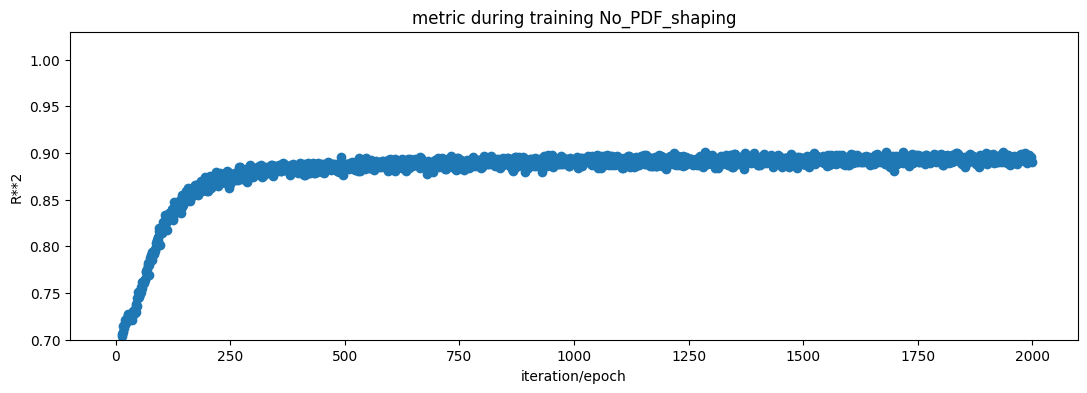

Training loss: tensor(0.0951, grad_fn=<MseLossBackward0>)
Training R**2: 0.8942261131680249
Test loss - scaled: tensor(0.1320, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(331365.6250, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.8438001266207221
Testing R**2 - descaled: 0.843800132607511
*****
*****
Testing R**2 - Output: 0 o_prod_rt 0.843800132607511


In [28]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)

opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate   )
loss_fn = F.mse_loss


fit_y_scaled(PDFshapingOBJ.N_EPOCHS, model, loss_fn, opt)


pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,         PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,       PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))

PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [29]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(7971.653, 7980.0)
**************************************************
preds, real
(8424.073, 8280.0)
**************************************************
preds, real
(10788.712, 10800.0)
**************************************************
preds, real
(8674.499, 8200.0)
**************************************************
preds, real
(9586.921, 9560.0)
**************************************************
preds, real
(8203.855, 8400.0)
**************************************************
preds, real
(6459.5913, 6510.0)
**************************************************
preds, real
(10151.894, 10400.0)
**************************************************
preds, real
(8771.628, 8460.0)
**************************************************
preds, real
(7962.216, 8030.0)
**************************************************
preds, real
(7355.6104, 7850.0)
**************************************************
preds, real
(10379.337, 10300.0)
********

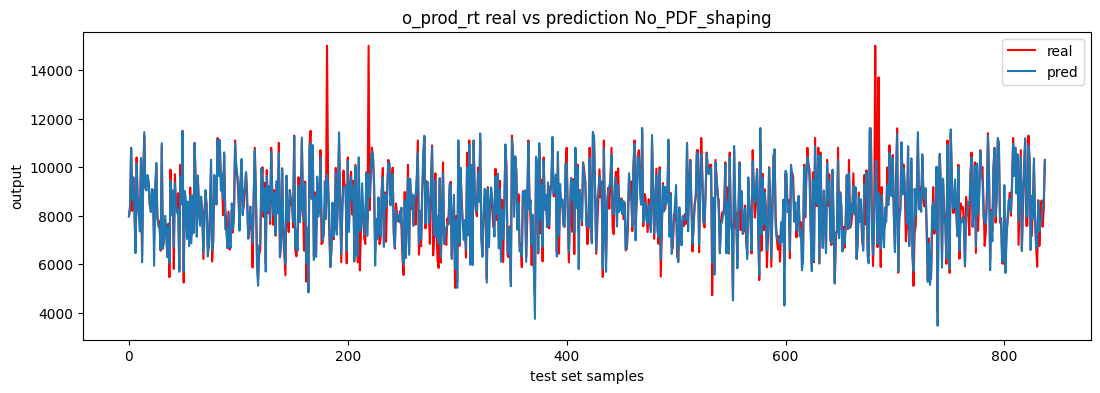

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


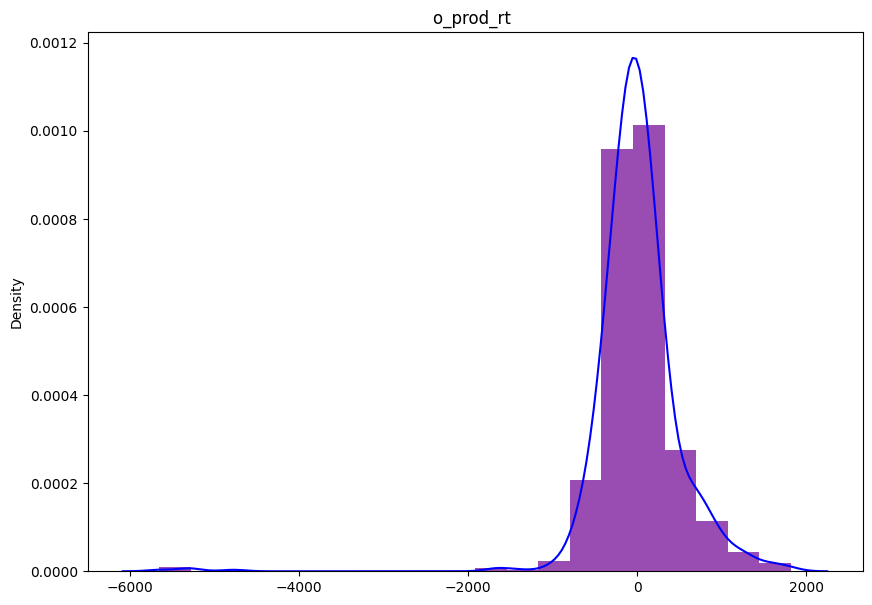

In [30]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## Export ONNX model


In [31]:


name_to_use_onnx = "ONNXmodels/F1plusF2NNs_" + ONNX_name + ".onnx"

model.eval()

dummy_input = torch.randn(1, 14)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  name_to_use_onnx, 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)




## To compare NNs to XGBoost


In [32]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [33]:

pred_descaled


tensor([[ 7892.0151],
        [ 8445.1309],
        [11039.8887],
        [ 8636.4082],
        [ 9545.5605],
        [ 8473.4043],
        [ 6888.5137],
        [10050.9746],
        [ 8614.9395],
        [ 8132.0522],
        [ 7745.7925],
        [10268.2119],
        [ 6228.4902],
        [ 9198.7617],
        [11383.8477],
        [ 9110.6826],
        [ 8986.7256],
        [ 9692.7148],
        [ 9468.0059],
        [ 8688.5742],
        [ 8151.6519],
        [ 8909.5850],
        [ 8881.8398],
        [ 6759.9341],
        [ 8970.3047],
        [ 9957.7188],
        [ 7800.2881],
        [ 7556.8428],
        [ 7446.7822],
        [ 6567.4595],
        [10922.6367],
        [ 6802.8701],
        [ 7107.4438],
        [ 7860.7422],
        [ 7406.5469],
        [ 6072.4297],
        [ 7607.9141],
        [ 5917.1484],
        [ 9380.9141],
        [ 8188.3438],
        [ 8968.5938],
        [ 6767.0161],
        [ 9585.2246],
        [ 8303.1328],
        [ 8209.1650],
        [ 

In [34]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.8747203473337327
Testing R**2 - descaled: 0.8747203445436919



## Results for g(x) = F1(x) + F2(x) with PDF shaping

F1 = Linear

F2 = Nonlinear


In [35]:

def fit_y_scaled_PDF(num_epochs, num_epochs_pdf, model, loss_fn, opt, kl_loss, scheduler):
    
    PDFshapingOBJ.list_metric = []
      
    for epoch in range(num_epochs):
        for xb, yb in PDFshapingOBJ.train_dl:
            
            pred_descaled, pred_scaled = model(xb)
            loss = loss_fn(pred_scaled, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            
        if epoch % 200 == 0:
            print(epoch, " loss= ", loss)
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
        r2_avg = torch.mean(torch.tensor(
                r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(r2_avg.detach().numpy())
        
        
    opt = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol  )    
        
    for epoch in range(num_epochs_pdf):
        
        pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
       
        error =   pred_scaled.float() - PDFshapingOBJ.y_train_tr_scaled.float()          ## 715  x 1
        
        basisFunc = PDFshapingOBJ.train_multiple_kernels_per_output( error )             ## 1000 x 1
        
        p_pred = basisFunc.float() 
        q_real = PDFshapingOBJ.impulse_func_vector_vals.unsqueeze(1).float() 
        
        
        diff = ( p_pred - q_real )**2              ## 1000 x 1
        diff = diff * PDFshapingOBJ.quadratic_weights.unsqueeze(1)      
          
        
        loss = torch.mean( diff  ) 
        

        ## loss_diff = loss_fn(p_pred, q_real)
        ## input_kl  = F.log_softmax(p_pred, dim=0) # F.log_softmax(p_kl)
        ## target_kl = F.softmax(    q_real, dim=0) # F.softmax(q_kl)
        ## loss =  loss_diff   ## kl_loss(input_kl, target_kl)  ##   +  torch.std(p_pred)
        
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
      
        
        ## PDFshapingOBJ.updateImpulseGaussian_with_new_standard_deviation(decay_impulse_std )
        

        ## print(epoch, " loss= ", loss)
        if epoch % 5000 == 0:
            print(epoch, " loss= ", loss)
            print(PDFshapingOBJ.impulse_func_vector_vals.shape )
            print(PDFshapingOBJ.quadratic_weights.shape)
            print(error.shape)
            print(basisFunc.shape)
            ##### PDFshapingOBJ.print_errors_kdes(  error, basisFunc )
            print(PDFshapingOBJ.impulse_func_vector_vals.shape)
            print('Epoch-{0} lr: {1}'.format(epoch, opt.param_groups[0]['lr']))
      

        r2_avg = torch.mean(torch.tensor(
                 r2_score( pred_scaled.detach().numpy(),  PDFshapingOBJ.y_train_tr_scaled.numpy()  )
        ))
        PDFshapingOBJ.list_metric.append(  r2_avg.detach().numpy()  )
        
        
            
    PDFshapingOBJ.func_plot_performance()
            
    pred_descaled, pred_scaled = model(PDFshapingOBJ.X_train_tr)
    print('Training loss:', loss_fn(  pred_scaled,       PDFshapingOBJ.y_train_tr_scaled          ))
    print('Training R**2:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_train_tr_scaled.numpy() ))
    


In [36]:

PDFshapingOBJ.the_string           = "With_PDF_shaping"
PDFshapingOBJ.furnace_model_name   = ONNX_name

PDFshapingOBJ.learning_rate_pdfcontrol  = 0.001       ## 0.001
PDFshapingOBJ.N_EPOCHS_PDF              = 30000
PDFshapingOBJ.N_EPOCHS                  = 0

decay_impulse_std                       = PDFshapingOBJ.std_impulse / PDFshapingOBJ.N_EPOCHS_PDF 


10000
0  loss=  tensor(0.0277, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-0 lr: 0.001
5000  loss=  tensor(0.0029, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-5000 lr: 0.001
10000  loss=  tensor(0.0027, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-10000 lr: 0.001
15000  loss=  tensor(0.0020, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-15000 lr: 0.001
20000  loss=  tensor(0.0020, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch.Size([1000, 1])
torch.Size([1000])
Epoch-20000 lr: 0.001
25000  loss=  tensor(0.0019, grad_fn=<MeanBackward0>)
torch.Size([1000])
torch.Size([1000])
torch.Size([3350, 1])
torch

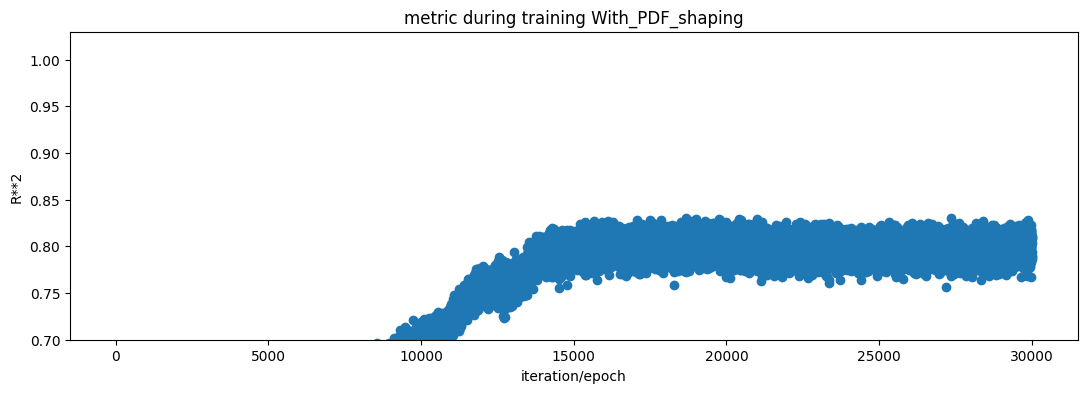

Training loss: tensor(0.2048, grad_fn=<MseLossBackward0>)
Training R**2: 0.7845540337798669
Test loss - scaled: tensor(0.2038, grad_fn=<MseLossBackward0>)
Test loss - descaled: tensor(511513.6562, grad_fn=<MseLossBackward0>)
Testing R**2 - scaled: 0.7751450116443463
Testing R**2 - descaled: 0.7751450099352155
*****
*****
Testing R**2 - Output: 0 o_prod_rt 0.7751450099352155


In [37]:

model = F1plusF2_SIO(
             PDFshapingOBJ.x_means, 
             PDFshapingOBJ.x_deviations, 
             PDFshapingOBJ.y_means, 
             PDFshapingOBJ.y_deviations
)



opt         = torch.optim.Adam(   model.parameters(), lr=PDFshapingOBJ.learning_rate_pdfcontrol    )


step_size_scheduler = int(PDFshapingOBJ.N_EPOCHS_PDF / 3)
print(step_size_scheduler)
                          
scheduler   = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma=0.1)



loss_fn      = F.mse_loss
kl_loss      = nn.KLDivLoss(reduction="batchmean")
loss_softmax = F.binary_cross_entropy


fit_y_scaled_PDF(PDFshapingOBJ.N_EPOCHS, PDFshapingOBJ.N_EPOCHS_PDF, model, loss_fn, opt, kl_loss, scheduler)

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)
print('Test loss - scaled:',   loss_fn(     pred_scaled,       PDFshapingOBJ.y_test_tr_scaled          ))
print('Test loss - descaled:', loss_fn(     pred_descaled,     PDFshapingOBJ.y_test_tr                 ))
print('Testing R**2 - scaled:',   r2_score( pred_scaled.detach().numpy(),PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()   ))


PDFshapingOBJ.print_individual_Rsquare(pred_descaled, PDFshapingOBJ.y_test_tr)


In [38]:

list_preds = []
list_reals = []

for i in range(len(PDFshapingOBJ.X_test_tr)):
    print("**************************************************")
    print("preds, real")
    preds_descaled, preds_scaled = model(PDFshapingOBJ.X_test_tr[i])

    np_pred = preds_descaled[0].detach().numpy()              ## [0]
    np_real = PDFshapingOBJ.y_test_tr[i].detach().numpy()

    for j in range(len(np_pred)):
        print((np_pred[j], np_real[j]))
        list_preds.append(np_pred[j])
        list_reals.append(np_real[j])


**************************************************
preds, real
(7980.855, 7980.0)
**************************************************
preds, real
(8332.723, 8280.0)
**************************************************
preds, real
(10931.103, 10800.0)
**************************************************
preds, real
(8844.843, 8200.0)
**************************************************
preds, real
(9665.213, 9560.0)
**************************************************
preds, real
(8474.325, 8400.0)
**************************************************
preds, real
(6836.2485, 6510.0)
**************************************************
preds, real
(10340.381, 10400.0)
**************************************************
preds, real
(8554.866, 8460.0)
**************************************************
preds, real
(7976.3354, 8030.0)
**************************************************
preds, real
(7766.093, 7850.0)
**************************************************
preds, real
(10324.864, 10300.0)
********

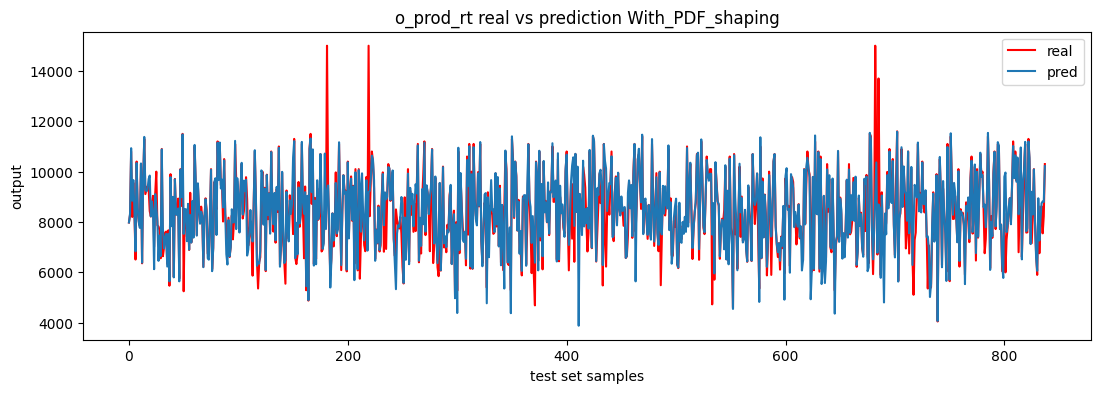

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


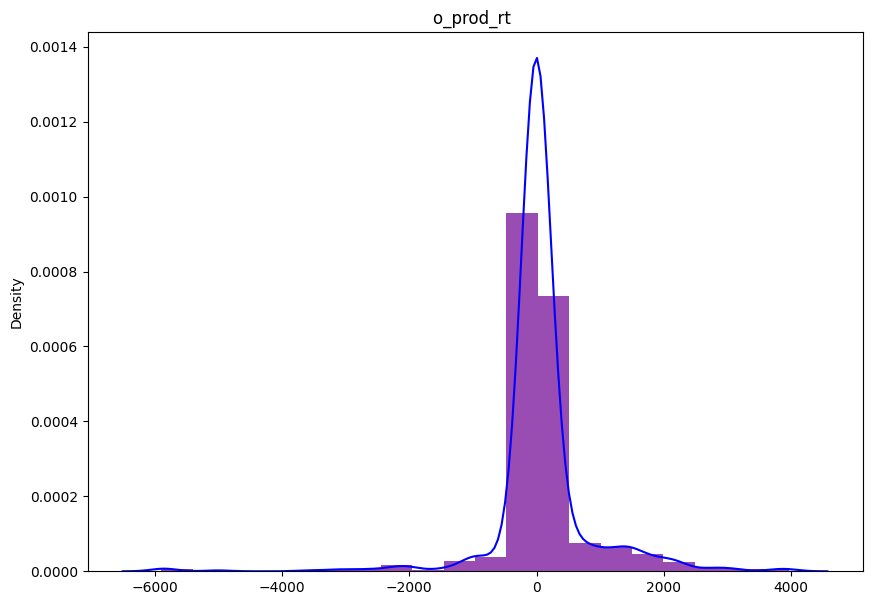

In [39]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## To compare to NNs to XGBoost


In [40]:

##      y_pred = regressor.predict(PDFshapingOBJ.X_test )

pred_descaled, pred_scaled = model(PDFshapingOBJ.X_test_tr)


In [41]:

## y_pred

pred_descaled


tensor([[ 7952.0430],
        [ 8355.6143],
        [10954.5283],
        [ 8846.9287],
        [ 9748.3896],
        [ 8474.3096],
        [ 6456.4458],
        [10340.7236],
        [ 8515.2383],
        [ 7975.7012],
        [ 7813.2231],
        [10327.4609],
        [ 6329.6973],
        [ 9580.4902],
        [11461.5039],
        [ 9185.0830],
        [ 9258.4561],
        [10946.0000],
        [ 8999.7676],
        [ 8391.3574],
        [ 8071.4229],
        [ 8847.4717],
        [ 8486.4248],
        [ 9670.0420],
        [ 9140.6055],
        [ 7213.4443],
        [ 7629.2554],
        [ 6872.4746],
        [ 7461.3828],
        [ 6646.6860],
        [10938.5977],
        [ 6541.1191],
        [ 7119.7163],
        [ 7373.1445],
        [ 7527.6626],
        [ 6300.9141],
        [ 7460.5649],
        [ 5557.4980],
        [ 9782.2822],
        [ 7851.4678],
        [ 8910.8457],
        [ 7362.2544],
        [ 9716.7969],
        [ 8366.4209],
        [ 8285.6758],
        [ 

In [42]:

## r2_score( PDFshapingOBJ.y_test, y_pred )

print('Testing R**2 - scaled:', r2_score( pred_scaled.detach().numpy(), PDFshapingOBJ.y_test_tr_scaled.numpy() ))
print('Testing R**2 - descaled:', r2_score( pred_descaled.detach().numpy(), PDFshapingOBJ.y_test_tr.numpy()    ))


Testing R**2 - scaled: 0.7276666858138383
Testing R**2 - descaled: 0.7276666985028664



## Export ONNX model


In [43]:

'''

model.eval()

dummy_input = torch.randn(1, 6)


input_names = ["input1"]
output_names = ["output1", "output2"]

torch.onnx.export(
  model, 
  dummy_input, 
  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", 
  verbose=False, 
  input_names  = input_names,
  output_names = output_names
)

'''


'\n\nmodel.eval()\n\ndummy_input = torch.randn(1, 6)\n\n\ninput_names = ["input1"]\noutput_names = ["output1", "output2"]\n\ntorch.onnx.export(\n  model, \n  dummy_input, \n  "ONNXmodels/s894TuyereExitVeloMsPDFshapingRC.onnx", \n  verbose=False, \n  input_names  = input_names,\n  output_names = output_names\n)\n\n'


## XGBoost


In [44]:

regressor = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [45]:

regressor.fit(PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [46]:

print( len(PDFshapingOBJ.X_train  ))
print( len(PDFshapingOBJ.y_train  ))
  


3350
3350


In [47]:

## columns_thing = ['i_h2_inj_kg_thm', 'i_pul_coal_inj_kg_thm', 'i_nat_gas_inj_kg_thm', 'i_nat_gas_t_k', 
##                  'i_o2_vol_perce', 'i_hot_blast_temp_k', ]



## pd.DataFrame(regressor.feature_importances_.reshape(1, -1), columns=columns_thing)


In [48]:

y_pred = regressor.predict(PDFshapingOBJ.X_test )


In [49]:

y_pred


array([ 7888.6924,  8268.651 , 11003.484 ,  8165.751 ,  9517.549 ,
        8595.774 ,  6440.6357, 10242.66  ,  8452.956 ,  7982.581 ,
        7976.9277, 10644.131 ,  6324.5767,  9211.584 , 11684.748 ,
        9295.662 ,  8988.227 ,  9325.924 ,  9402.606 ,  8380.111 ,
        7793.4854,  8799.439 ,  8481.632 ,  6877.707 ,  9032.156 ,
       10126.734 ,  7902.437 ,  7769.579 ,  7613.305 ,  6732.0806,
       10964.8125,  6609.0337,  7133.522 ,  7465.009 ,  7397.4785,
        6168.058 ,  7539.3906,  5846.083 , 10062.484 ,  7991.3105,
        9018.612 ,  6808.0767,  9817.105 ,  8310.362 ,  8346.113 ,
        8781.381 ,  5958.4053,  9805.621 ,  8605.744 , 11272.169 ,
        5214.283 ,  8457.495 ,  8311.232 ,  7283.735 ,  8043.034 ,
        6966.5054,  8959.719 ,  7471.7446,  8455.794 ,  7271.3345,
       11074.428 ,  8347.296 ,  7433.706 ,  9923.319 ,  8805.755 ,
        8367.868 ,  8964.417 ,  8044.161 ,  6506.94  ,  7907.802 ,
        8728.283 ,  8065.5073,  6653.7183,  6721.8716,  7945.1

In [50]:

mean_squared_error(PDFshapingOBJ.y_test , y_pred)


187669.97

In [51]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9237329521249746

In [52]:

len(y_pred) 


838

In [53]:

list_preds = []
list_reals = []

print( "preds, real"   )
  
for j in range(   len(y_pred)    ):
    print(   y_pred[j], PDFshapingOBJ.y_test[j][0]   )
    
    list_preds.append(   y_pred[j]   )
    list_reals.append(  PDFshapingOBJ.y_test[j][0]   )


preds, real
7888.6924 7980.0
8268.651 8280.0
11003.484 10800.0
8165.751 8200.0
9517.549 9560.0
8595.774 8400.0
6440.6357 6510.0
10242.66 10400.0
8452.956 8460.0
7982.581 8030.0
7976.9277 7850.0
10644.131 10300.0
6324.5767 6360.0
9211.584 9660.0
11684.748 11300.0
9295.662 9110.0
8988.227 9270.0
9325.924 9420.0
9402.606 9320.0
8380.111 8430.0
7793.4854 8220.0
8799.439 8770.0
8481.632 9040.0
6877.707 7020.0
9032.156 9120.0
10126.734 10000.0
7902.437 7870.0
7769.579 7820.0
7613.305 7660.0
6732.0806 6560.0
10964.8125 10900.0
6609.0337 6640.0
7133.522 6970.0
7465.009 7580.0
7397.4785 7620.0
6168.058 6340.0
7539.3906 7670.0
5846.083 5470.0
10062.484 9900.0
7991.3105 8050.0
9018.612 8990.0
6808.0767 5810.0
9817.105 9710.0
8310.362 8300.0
8346.113 8380.0
8781.381 8930.0
5958.4053 5750.0
9805.621 10100.0
8605.744 8640.0
11272.169 11500.0
5214.283 5250.0
8457.495 8460.0
8311.232 8450.0
7283.735 7420.0
8043.034 8140.0
6966.5054 6890.0
8959.719 9160.0
7471.7446 7190.0
8455.794 8650.0
7271.3345 7500

In [54]:

len( list_preds )


838

In [55]:

len( list_reals )


838

In [56]:

PDFshapingOBJ.the_string           = "XGBoost"
PDFshapingOBJ.furnace_model_name   = ONNX_name


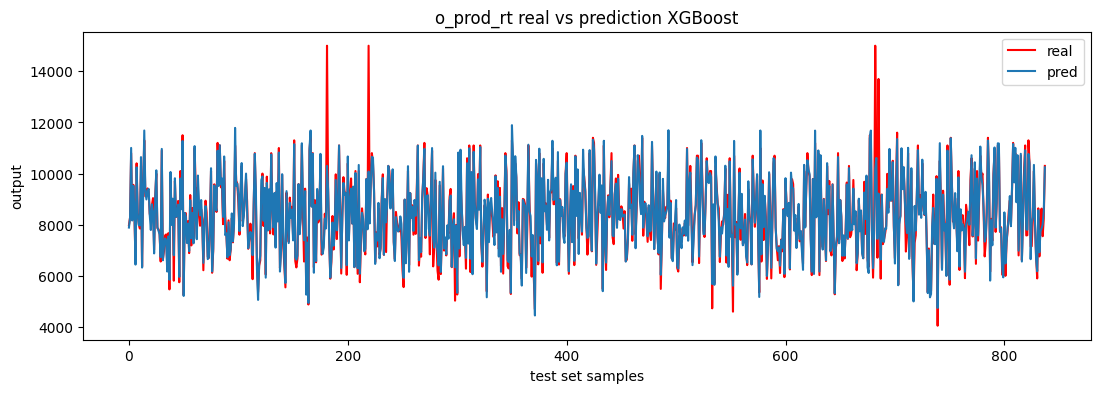

/Users/user/Desktop/CIVS_last_Phase/Forward/2025july/NewDataset/PDFshapingUtils.py:353: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error, bins=n_bins, color="blue")


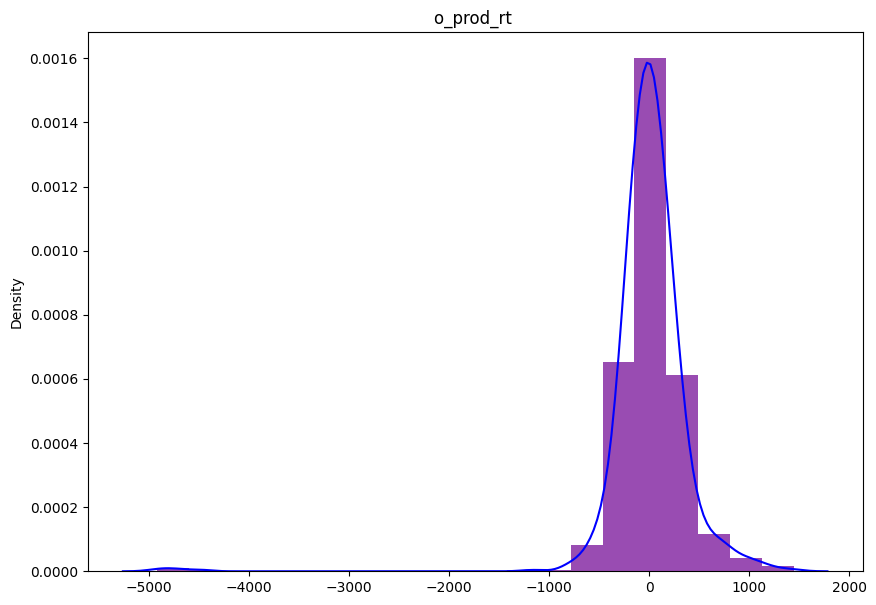

In [57]:

PDFshapingOBJ.plot_preds_vs_reals( list_preds, list_reals )



## ONNX and XGboost


In [58]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)


In [59]:


print(model)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=0, gpu_id=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=1, ...)


In [60]:

model.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=3, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [61]:

y_pred = model.predict(PDFshapingOBJ.X_test )


In [62]:

y_pred


array([ 7888.6924,  8268.651 , 11003.484 ,  8165.751 ,  9517.549 ,
        8595.774 ,  6440.6357, 10242.66  ,  8452.956 ,  7982.581 ,
        7976.9277, 10644.131 ,  6324.5767,  9211.584 , 11684.748 ,
        9295.662 ,  8988.227 ,  9325.924 ,  9402.606 ,  8380.111 ,
        7793.4854,  8799.439 ,  8481.632 ,  6877.707 ,  9032.156 ,
       10126.734 ,  7902.437 ,  7769.579 ,  7613.305 ,  6732.0806,
       10964.8125,  6609.0337,  7133.522 ,  7465.009 ,  7397.4785,
        6168.058 ,  7539.3906,  5846.083 , 10062.484 ,  7991.3105,
        9018.612 ,  6808.0767,  9817.105 ,  8310.362 ,  8346.113 ,
        8781.381 ,  5958.4053,  9805.621 ,  8605.744 , 11272.169 ,
        5214.283 ,  8457.495 ,  8311.232 ,  7283.735 ,  8043.034 ,
        6966.5054,  8959.719 ,  7471.7446,  8455.794 ,  7271.3345,
       11074.428 ,  8347.296 ,  7433.706 ,  9923.319 ,  8805.755 ,
        8367.868 ,  8964.417 ,  8044.161 ,  6506.94  ,  7907.802 ,
        8728.283 ,  8065.5073,  6653.7183,  6721.8716,  7945.1

In [63]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9237329521249746

In [64]:

initial_types = [(
         'float_input', 
         FloatTensorType(     [ None, PDFshapingOBJ.X.shape[1] ]       )
)]


In [65]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

## target_opset=7

onnx_model = onnxmltools.convert_xgboost(model, initial_types=initial_types)

onnxmltools.utils.save_model(onnx_model, onnx_name_to_use)


In [66]:

onnx_name_to_use = 'ONNXmodels/xgboost_' + ONNX_name + '_ort.onnx'

# Setup runtime. This instantiates an ONNX inference session and loads the persisted model.
sess = rt.InferenceSession( onnx_name_to_use )


In [67]:

# Get model metadata to enable mapping of new input to the runtime model
input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [68]:

input_name 


'float_input'

In [69]:

label_name


'variable'

In [70]:

# Create predictions. The inputs are the xtest values, and they are being casted as type float32.
pred_onnx = sess.run([label_name], {input_name: PDFshapingOBJ.X_test.astype(np.float32)})[0]


In [71]:

# Print first 10 predictions
print("Prediction:\n", pred_onnx[0:10])


Prediction:
 [[ 7888.6934]
 [ 8268.649 ]
 [11003.483 ]
 [ 8165.749 ]
 [ 9517.545 ]
 [ 8595.773 ]
 [ 6440.636 ]
 [10242.66  ]
 [ 8452.953 ]
 [ 7982.582 ]]


In [72]:

test_count = 10
test_cases = PDFshapingOBJ.X_test[0:test_count]
local_pred = model.predict(test_cases)
print(f"Local predictions are: {local_pred}")


Local predictions are: [ 7888.6924  8268.651  11003.484   8165.751   9517.549   8595.774
  6440.6357 10242.66    8452.956   7982.581 ]


In [73]:

test_cases


array([[  20. ,    0. ,    0. ,    0. ,   21. ,  300. ,    0. , 1448. ,
         195. ,    0. ,    1. ,    0. ,    0. ,    0. ],
       [  20. ,    0. ,    0. ,    0. ,   30. ,  300. ,    0. , 1448. ,
         195. ,    0. ,    5. ,    0. ,    0. ,    0. ],
       [  40. ,    0. ,    0. ,    0. ,   30. ,    0. ,  300. , 1600. ,
         230. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,   90. ,    0. ,    0. ,   21. ,  300. ,    0. , 1200. ,
         230. ,    5.7,    1. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  150. ,   27. ,  500. ,    0. , 1200. ,
         195. ,    5.7,    7. ,    0. ,    0. ,    0. ],
       [  30. ,    0. ,    0. ,    0. ,   24. ,  300. ,    0. , 1600. ,
         195. ,   11.4,    7. ,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. ,  120. ,   24. ,  300. ,    0. , 1480. ,
         195. ,    5.7,    3. ,    0. ,    0. ,    0. ],
       [  40. ,    0. ,    0. ,    0. ,   21. ,    0. ,  300. , 1200. ,
         230. ,    5.7,  


## ONNX, XGBoost, and SKlearn pipeline


In [74]:

update_registered_converter(
    XGBRegressor, 'XGBoostXGBRegressor',
    calculate_linear_regressor_output_shapes, 
    convert_xgboost
)


In [75]:

model = xgb.XGBRegressor(
    n_estimators=100,
    reg_lambda=1,
    gamma=0,
    max_depth=3
)

pipe = Pipeline([
            ('xgb', model) 
])



pipe.fit( PDFshapingOBJ.X_train, PDFshapingOBJ.y_train)


Pipeline(steps=[('xgb',
                 XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                              colsample_bylevel=1, colsample_bynode=1,
                              colsample_bytree=1, early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              gamma=0, gpu_id=-1, grow_policy='depthwise',
                              importance_type=None, interaction_constraints='',
                              learning_rate=0.300000012, max_bin=256,
                              max_cat_to_onehot=4, max_delta_step=0,
                              max_depth=3, max_leaves=0, min_child_weight=1,
                              missing=nan, monotone_constraints='()',
                              n_estimators=100, n_jobs=0, num_parallel_tree=1,
                              predictor='auto', random_state=0, reg_alpha=0,
                              reg_lambda=1, ...))])

In [76]:

y_pred = pipe.predict(PDFshapingOBJ.X_test )


In [77]:

y_pred


array([ 7888.6924,  8268.651 , 11003.484 ,  8165.751 ,  9517.549 ,
        8595.774 ,  6440.6357, 10242.66  ,  8452.956 ,  7982.581 ,
        7976.9277, 10644.131 ,  6324.5767,  9211.584 , 11684.748 ,
        9295.662 ,  8988.227 ,  9325.924 ,  9402.606 ,  8380.111 ,
        7793.4854,  8799.439 ,  8481.632 ,  6877.707 ,  9032.156 ,
       10126.734 ,  7902.437 ,  7769.579 ,  7613.305 ,  6732.0806,
       10964.8125,  6609.0337,  7133.522 ,  7465.009 ,  7397.4785,
        6168.058 ,  7539.3906,  5846.083 , 10062.484 ,  7991.3105,
        9018.612 ,  6808.0767,  9817.105 ,  8310.362 ,  8346.113 ,
        8781.381 ,  5958.4053,  9805.621 ,  8605.744 , 11272.169 ,
        5214.283 ,  8457.495 ,  8311.232 ,  7283.735 ,  8043.034 ,
        6966.5054,  8959.719 ,  7471.7446,  8455.794 ,  7271.3345,
       11074.428 ,  8347.296 ,  7433.706 ,  9923.319 ,  8805.755 ,
        8367.868 ,  8964.417 ,  8044.161 ,  6506.94  ,  7907.802 ,
        8728.283 ,  8065.5073,  6653.7183,  6721.8716,  7945.1

In [78]:

r2_score( PDFshapingOBJ.y_test, y_pred )


0.9237329521249746

In [79]:

onnx_name_to_use = 'pipeline_xgboost_' + ONNX_name

model_onnx = convert_sklearn(
    pipe, 
    onnx_name_to_use,
    [ ('input', FloatTensorType([None, PDFshapingOBJ.X.shape[1]])) ],
    target_opset={'': 7, 'ai.onnx.ml': 1})


In [80]:

onnx_name_to_use = "ONNXmodels/pipeline_xgboost_" + ONNX_name + ".onnx"

with open(onnx_name_to_use, "wb") as f:
    f.write(model_onnx.SerializeToString())
    

In [81]:
onx = to_onnx(pipe, PDFshapingOBJ.X_test.astype(np.float32),
              target_opset={'': 7, 'ai.onnx.ml': 1})

sess = rt.InferenceSession(onx.SerializeToString())
pred_onx = sess.run(None, {"X": PDFshapingOBJ.X_test[:5].astype(np.float32)})
print("predict", pred_onx[0].ravel())



predict [ 7888.6924  8268.651  11003.484   8165.751   9517.549 ]


In [82]:

input_name = sess.get_inputs()[0].name
label_name = sess.get_outputs()[0].name


In [83]:
label_name 

'variable'

In [84]:
input_name 

'X'